# Project 3: Supply Chain Analytics - Demand Forecasting & Anomaly Detection

## Week 2

### Member 2: Visualization, Validation & Business Analysis

#### Objective

- Load processed anomaly detection datasets.
- Merge anomaly labels into a unified dataset.
- Verify anomaly columns.
- Export the final dataset for visualization and business analysis.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Step 2: Load Member Datasets

In [2]:
zscore_df = pd.read_excel("z-score_retail_storeinventory.xlsx")

merged_df = pd.read_csv("final_merged_dataset.csv")

## Step 3: Verify Dataset Structure

In [3]:
print("Z-Score Dataset")

print(zscore_df.shape)

print(zscore_df.columns)

print()

print("Merged Dataset")

print(merged_df.shape)

print(merged_df.columns)

Z-Score Dataset
(73100, 16)
Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Anomaly'],
      dtype='object')

Merged Dataset
(73100, 17)
Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'IQR_Anomaly', 'IsolationForest'],
      dtype='object')


## Step 4: Merge Z-Score Anomaly Column

In [4]:
merged_df["ZScore_Anomaly"] = zscore_df["Anomaly"]

## Step 5: Verify Anomaly Columns

In [5]:
merged_df[
    [
        "ZScore_Anomaly",
        "IQR_Anomaly",
        "IsolationForest"
    ]
].head()

,ZScore_Anomaly,IQR_Anomaly,IsolationForest
0,False,0,0
1,False,0,0
2,False,0,0
3,False,0,0
4,False,0,0


## Step 6: Export Final Dataset

In [6]:
merged_df.to_excel(
    "final_anomaly_dataset.xlsx",
    index=False
)

print("Final anomaly dataset exported successfully.")

Final anomaly dataset exported successfully.


### Observation

Successfully merged anomaly labels from Z-Score, IQR, and Isolation Forest into a unified dataset. The exported dataset will be used for visualization, comparison, and business validation in the upcoming analysis steps.

## Step 7: Visualize Z-Score Anomalies

In this step, anomalies detected using the Z-Score method are visualized on a time-series graph. The visualization highlights statistically unusual sales observations that deviate significantly from the normal sales pattern.

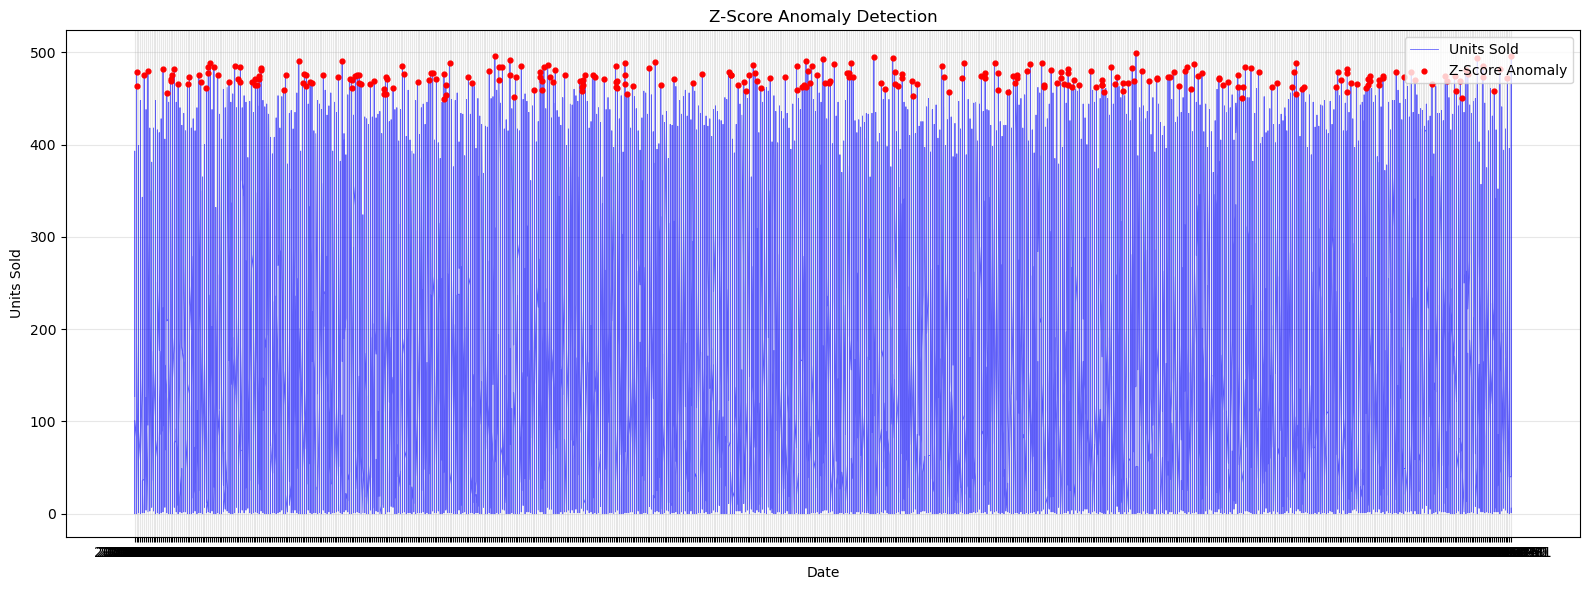

In [7]:
plt.figure(figsize=(16,6))

plt.plot(
    merged_df["Date"],
    merged_df["Units Sold"],
    color="blue",
    linewidth=0.6,
    alpha=0.6,
    label="Units Sold"
)

plt.scatter(
    merged_df.loc[
        merged_df["ZScore_Anomaly"]==True,
        "Date"
    ],
    merged_df.loc[
        merged_df["ZScore_Anomaly"]==True,
        "Units Sold"
    ],
    color="red",
    s=12,
    label="Z-Score Anomaly",
    zorder=3
)

plt.title("Z-Score Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

The Z-Score visualization highlights statistically unusual sales observations. Red points indicate sales values that significantly deviate from the normal sales pattern and may represent abnormal demand, inventory issues, or unexpected business events.

## Step 8: Visualize IQR Anomalies

In this step, anomalies detected using the Interquartile Range (IQR) method are visualized on a time-series graph. The visualization highlights observations that fall outside the expected interquartile range and may indicate unusual sales behavior.

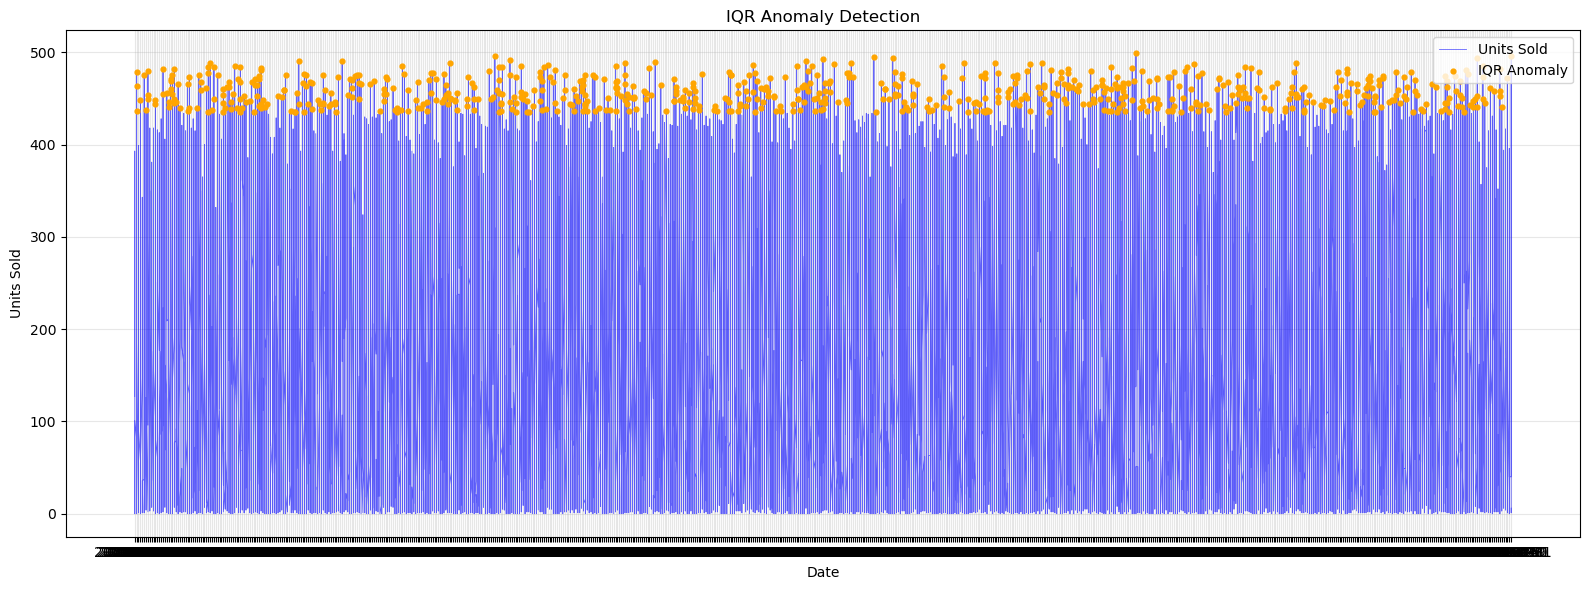

In [8]:
plt.figure(figsize=(16,6))

plt.plot(
    merged_df["Date"],
    merged_df["Units Sold"],
    color="blue",
    linewidth=0.6,
    alpha=0.6,
    label="Units Sold"
)

plt.scatter(
    merged_df.loc[
        merged_df["IQR_Anomaly"]==True,
        "Date"
    ],
    merged_df.loc[
        merged_df["IQR_Anomaly"]==True,
        "Units Sold"
    ],
    color="orange",
    s=12,
    label="IQR Anomaly",
    zorder=3
)

plt.title("IQR Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

The IQR visualization identifies observations outside the expected interquartile range. Orange points represent potential anomalies that may indicate unusual sales behavior caused by demand fluctuations, inventory issues, or operational events.

## Step 9: Visualize Isolation Forest Anomalies

In this step, anomalies detected using the Isolation Forest algorithm are visualized on a time-series graph. The machine learning model identifies unusual sales observations by isolating abnormal data points instead of relying on statistical thresholds.

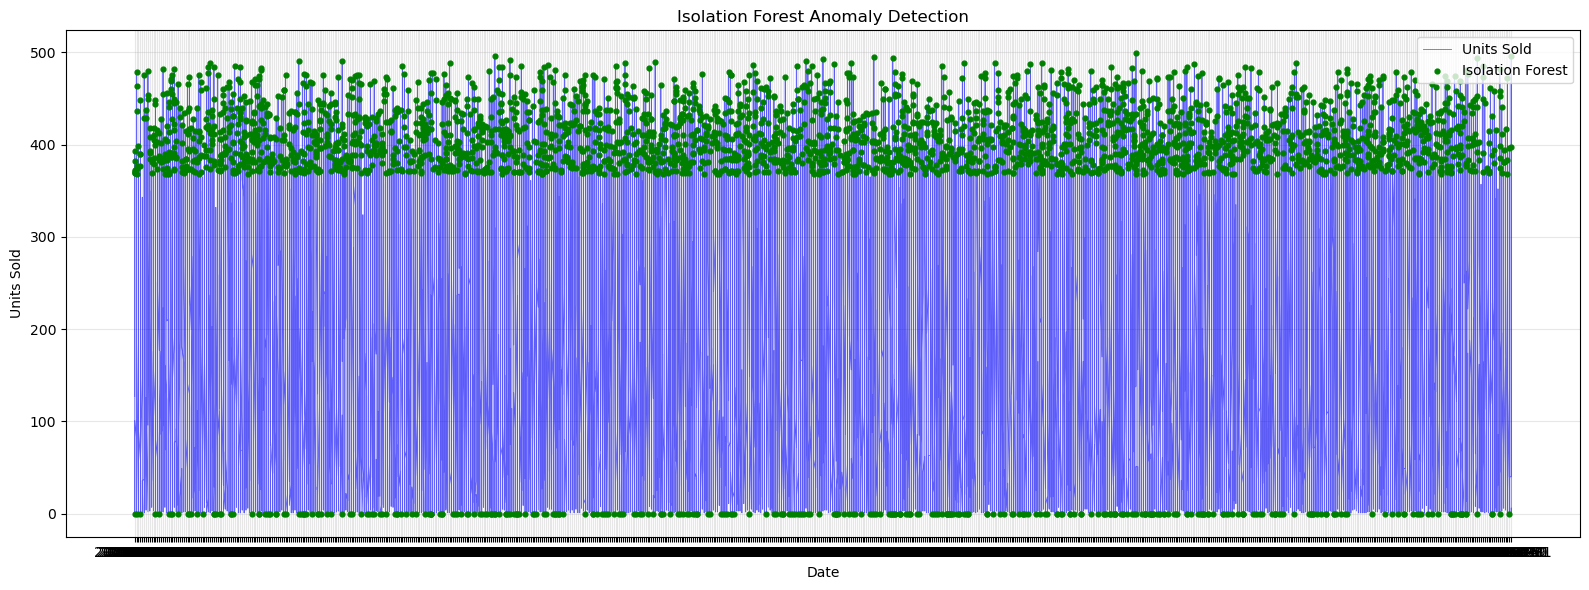

In [9]:
plt.figure(figsize=(16,6))

plt.plot(
    merged_df["Date"],
    merged_df["Units Sold"],
    color="blue",
    linewidth=0.6,
    alpha=0.6,
    label="Units Sold"
)

plt.scatter(
    merged_df.loc[
        merged_df["IsolationForest"] == 1,
        "Date"
    ],
    merged_df.loc[
        merged_df["IsolationForest"] == 1,
        "Units Sold"
    ],
    color="green",
    s=12,
    label="Isolation Forest",
    zorder=3
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

The Isolation Forest visualization highlights anomalies detected using a machine learning approach. Green points indicate unusual sales observations that may represent abnormal demand, inventory shortages, supplier delays, or unexpected operational events.

## Step 10: Compare Anomaly Detection Methods

In this step, anomaly detection results obtained using Z-Score, IQR, and Isolation Forest are compared. The comparison helps evaluate how each technique identifies unusual sales observations and supports selecting the most appropriate method for business analysis.

In [10]:
comparison_summary = pd.DataFrame({

    "Method":[
        "Z-Score",
        "IQR",
        "Isolation Forest"
    ],

    "Anomalies Detected":[

        merged_df["ZScore_Anomaly"].sum(),

        merged_df["IQR_Anomaly"].sum(),

        merged_df["IsolationForest"].sum()

    ]

})

comparison_summary

,Method,Anomalies Detected
0,Z-Score,284
1,IQR,715
2,Isolation Forest,3478


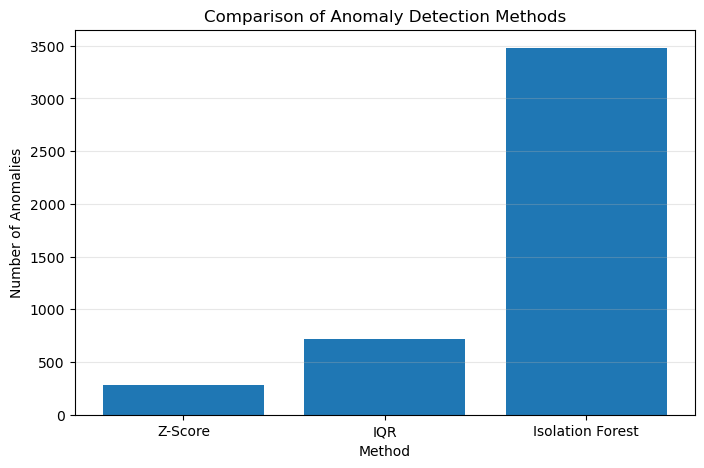

In [11]:
plt.figure(figsize=(8,5))

plt.bar(

    comparison_summary["Method"],

    comparison_summary["Anomalies Detected"]

)

plt.title("Comparison of Anomaly Detection Methods")

plt.xlabel("Method")

plt.ylabel("Number of Anomalies")

plt.grid(axis="y",alpha=0.3)

plt.show()

In [12]:
comparison_summary.to_excel(

    "anomaly_detection_summary.xlsx",

    index=False

)

print("Comparison summary exported successfully.")

Comparison summary exported successfully.


### Observation

The comparison indicates that each anomaly detection method identifies a different number of unusual observations. Z-Score and IQR rely on statistical thresholds, whereas Isolation Forest applies a machine learning approach. This comparison helps evaluate the sensitivity of each technique and supports better inventory planning and business decision-making.

## Step 11: Validate Business Scenarios

In this step, detected anomalies are validated by analyzing possible business scenarios such as holiday sales, stockouts, supplier delays, and demand spikes. This validation helps distinguish meaningful anomalies from normal business events and supports better decision-making.

In [13]:
business_validation = merged_df.copy()

business_validation["Business Scenario"] = np.where(

    business_validation["Units Sold"] >= business_validation["Units Sold"].quantile(0.95),

    "Possible Demand Spike / Holiday Sales",

    np.where(

        business_validation["Units Sold"] <= business_validation["Units Sold"].quantile(0.05),

        "Possible Stockout / Supplier Delay",

        "Normal Business Activity"

    )

)

business_validation.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,IQR_Anomaly,IsolationForest,ZScore_Anomaly,Business Scenario
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,0,0,False,Normal Business Activity
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,0,0,False,Normal Business Activity
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,0,0,False,Normal Business Activity
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,0,0,False,Normal Business Activity
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,0,0,False,Normal Business Activity


In [14]:
business_validation["Business Scenario"].value_counts()

Business Scenario
Normal Business Activity                 65751
Possible Stockout / Supplier Delay        3688
Possible Demand Spike / Holiday Sales     3661
Name: count, dtype: int64

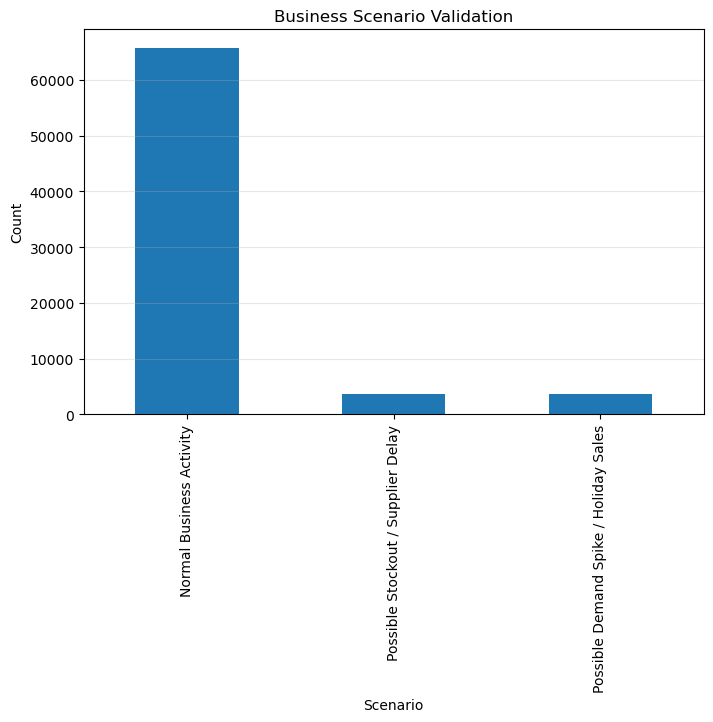

In [15]:
plt.figure(figsize=(8,5))

business_validation["Business Scenario"].value_counts().plot(

    kind="bar"

)

plt.title("Business Scenario Validation")

plt.xlabel("Scenario")

plt.ylabel("Count")

plt.grid(axis="y",alpha=0.3)

plt.show()

In [16]:
business_validation.to_excel(

    "business_validation.xlsx",

    index=False

)

print("Business validation exported successfully.")

Business validation exported successfully.


### Observation

Business validation categorizes detected anomalies into meaningful business scenarios. High sales values may indicate demand spikes or holiday sales, while low sales values may represent stockouts or supplier delays. This interpretation helps convert anomaly detection results into actionable business insights.